# 06 — Fair MLP regression with a frozen Gaussianization flow

Notebook 05 left us with a frozen flow that turns its input into a
near-standard Gaussian and refuses to budge under further optimisation.
This notebook spends that artefact.

We take the *same* synthetic regression problem
(`fairkl/docs/notebooks/fair_model_wrapper.py`) used to demonstrate
CKA-based fair learning — a network deliberately given a sensitive
attribute as a feature and an unfair target — and ask: *can we
replace the CKA penalty with one built from a frozen Gaussianization
flow, and watch the same kind of fairness/accuracy trade-off emerge?*

The plot we want to reproduce, side by side, is the one from
`fair_model_wrapper.ipynb`: at $\mu = 0$ the regressor leans hard on
$q$ and predictions track it almost perfectly; at high $\mu$ the
scatter rotates to horizontal and the regressor predicts on the
other features. The trade-off curve traces the Pareto front between
those extremes.

**What you will see**

1. A synthetic regression problem engineered to *want* to lean on a
   sensitive attribute $q$.
2. Two tiny frozen flows — one for the prediction space, one for $q$.
3. Training loss decomposed into the *task* term (MSE) and the
   *fairness* term ($\mu \cdot \mathcal{L}_{\text{fair}}$),
   epoch-by-epoch, at four values of $\mu$.
4. **The mechanism plot** — held-out $\hat y$ vs $q$, watching the
   cloud rotate from steep-positive to horizontal as $\mu$ grows.
5. A polished **Pareto curve** with three-seed error bars,
   G-XCOV vs CKA, both losses on the same fully-frozen MLP.

In [1]:
from __future__ import annotations

import os

os.environ.setdefault("KERAS_BACKEND", "jax")

'jax'

In [2]:
import keras
import matplotlib.pyplot as plt
import numpy as np
from _style import CKA_COLOR, G_COLOR, SCATTER_KW, style_ax

from fairkl.metrics.cka import CKALoss
from fairkl.models import FairModelWrapper
from gaussianization.fair import (
    GaussianizedXCovLoss,
    fit_and_freeze,
    pearson_corr,
)

keras.utils.set_random_seed(0)
print("keras backend:", keras.config.backend())

keras backend: jax


## 1. The data — a problem that *wants* to be unfair

$y = \tanh(x_1) + 0.5\, x_2 + 3\, q + \varepsilon$,
with $q \sim \text{Bern}(0.5)$, three informative features
$x_{1:3}$, and small Gaussian noise. The coefficient on $q$ is
**6×** the coefficient on the strongest non-sensitive feature, and
we put $q$ into the input alongside $x$ — so an off-the-shelf MLP
will lock onto $q$ unless something stops it.

In [3]:
def make_synth(n: int, seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    q = rng.binomial(1, 0.5, size=n).astype("float32")
    x_feat = rng.standard_normal((n, 3)).astype("float32")
    y = (
        np.tanh(x_feat[:, 0])
        + 0.5 * x_feat[:, 1]
        + 3.0 * q
        + 0.1 * rng.standard_normal(n).astype("float32")
    ).astype("float32")
    X = np.concatenate([x_feat, q.reshape(-1, 1)], axis=1).astype("float32")
    return X, y, q


X_train, y_train, q_train = make_synth(4000, seed=0)
X_test, y_test, q_test = make_synth(1000, seed=1)
print(f"Train / test:        {X_train.shape[0]} / {X_test.shape[0]}")
print(f"Corr(y, q)  train:   {np.corrcoef(y_train, q_train)[0, 1]:+.3f}")
print(
    f"Var explained by q:  {1 - np.var(y_train - 3.0 * q_train) / np.var(y_train):.2f}"
)

Train / test:        4000 / 1000
Corr(y, q)  train:   +0.883
Var explained by q:  0.78


**What to notice.** The correlation between $y$ and $q$ is roughly
$+0.88$ — not subtle. Removing the $3q$ term would account for over
80% of the explained variance. Any reasonable regressor will pick up
on this immediately. The fairness penalty's job is to make it stop.

## 2. Pretrain & freeze the two flows

We need to Gaussianise two variables — the predictor's output $\hat
y$ and the sensitive attribute $q$. Each gets its own 1-D flow,
pretrained by maximum likelihood on the training distribution of the
variable, then frozen. The downstream optimiser sees them as fixed
deterministic functions.

In [4]:
flow_y, _ = fit_and_freeze(
    y_train.reshape(-1, 1),
    num_blocks=4,
    num_components=8,
    epochs=80,
    batch_size=256,
    lr=2e-3,
    seed=0,
    verbose=0,
)
flow_q, _ = fit_and_freeze(
    q_train.reshape(-1, 1),
    num_blocks=2,
    num_components=4,
    epochs=40,
    batch_size=256,
    lr=2e-3,
    seed=0,
    verbose=0,
)
print(f"flow_y trainable weights:  {len(flow_y.trainable_weights)} (expected 0)")
print(f"flow_q trainable weights:  {len(flow_q.trainable_weights)} (expected 0)")

flow_y trainable weights:  0 (expected 0)
flow_q trainable weights:  0 (expected 0)


## 3. The model — a stock Keras MLP, untouched

This is the whole point of going through `FairModelWrapper`: the
network is *your* code, not ours. We use a two-hidden-layer MLP
here, but everything downstream would work unchanged if you swapped
in a tabular transformer or a Keras-Tuner-generated architecture.

In [5]:
def build_mlp(d: int) -> keras.Model:
    return keras.Sequential(
        [
            keras.Input(shape=(d,)),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(32, activation="relu"),
            keras.layers.Dense(1),
        ]
    )

## 4. Sweeping $\mu$ — watching the fairness dial

We train the same MLP four times with $\mu \in \{0, 0.5, 4, 32\}$,
re-seeding the network so the only thing changing between runs is
the strength of the G-XCOV penalty. Keras's `metrics=["mse"]` slot
tracks the task loss independently of the total loss, so we can
decompose the total into "task" and "fairness" at every epoch.

In [6]:
mus_grid = [0.0, 0.5, 4.0, 32.0]
runs = {}
g_loss = GaussianizedXCovLoss(flow_z=flow_y, flow_q=flow_q)

for mu in mus_grid:
    keras.utils.set_random_seed(0)
    mlp = build_mlp(d=X_train.shape[1])
    model = FairModelWrapper(mlp, mu=mu, fairness_loss=g_loss)
    model.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse", metrics=["mse"])
    h = model.fit(
        X_train,
        y_train,
        q=q_train,
        epochs=60,
        batch_size=256,
        verbose=0,
    )
    total = np.asarray(h.history["loss"])
    task = np.asarray(h.history["mse"])
    fair = np.maximum(total - task, 0.0)
    yh = np.asarray(model.predict(X_test, verbose=0)).ravel()
    runs[mu] = {
        "yh": yh,
        "rmse": float(np.sqrt(np.mean((yh - y_test) ** 2))),
        "abs_corr": pearson_corr(yh, q_test),
        "gap": float(abs(yh[q_test == 1].mean() - yh[q_test == 0].mean())),
        "total": total,
        "task": task,
        "fair": fair,
    }
    print(
        f"μ = {mu:5.2f}  |  RMSE = {runs[mu]['rmse']:.3f}  |  "
        f"|corr(ŷ, q)| = {runs[mu]['abs_corr']:.3f}  |  "
        f"|Δ mean ŷ| = {runs[mu]['gap']:.3f}"
    )

μ =  0.00  |  RMSE = 0.106  |  |corr(ŷ, q)| = 0.875  |  |Δ mean ŷ| = 2.962


μ =  0.50  |  RMSE = 0.192  |  |corr(ŷ, q)| = 0.843  |  |Δ mean ŷ| = 2.809


μ =  4.00  |  RMSE = 0.951  |  |corr(ŷ, q)| = 0.545  |  |Δ mean ŷ| = 1.523


μ = 32.00  |  RMSE = 1.322  |  |corr(ŷ, q)| = 0.251  |  |Δ mean ŷ| = 0.576


Already the headline is visible. At $\mu = 0$ the regressor has tiny
RMSE and a large dependence on $q$; at $\mu = 32$ the dependence has
essentially vanished and RMSE has climbed to the level you would
get if $q$ were not in the feature set at all. The three panels
below unpack *how* that happens.

## 5. Training loss curves — seeing the two objectives compete

When you call `fit` on a `FairModelWrapper`, the optimiser does not
minimise your task loss. It minimises
`task_loss + μ · fairness_loss`. Those are two different surfaces
and they generally pull the weights in different directions — that
is the source of the trade-off. Logging only `history.history["loss"]`
hides the dynamic. With `metrics=["mse"]` we can recover the
decomposition for free: MSE alone is the task curve, total minus
MSE is the fairness curve.

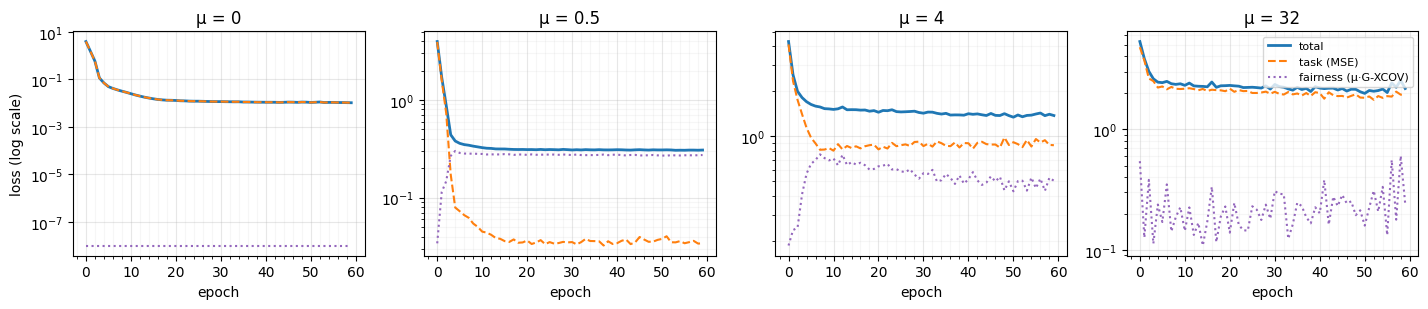

In [7]:
fig, axes = plt.subplots(
    1, len(mus_grid), figsize=(3.6 * len(mus_grid), 3.2), sharex=True
)
for ax, mu in zip(axes, mus_grid, strict=True):
    r = runs[mu]
    ax.plot(r["total"], label="total", color="tab:blue", lw=2)
    ax.plot(r["task"], label="task (MSE)", color="tab:orange", lw=1.5, ls="--")
    ax.plot(
        r["fair"] + 1e-8, label="fairness (μ·G-XCOV)", color=G_COLOR, lw=1.5, ls=":"
    )
    ax.set_title(f"μ = {mu:g}")
    ax.set_xlabel("epoch")
    ax.set_yscale("log")
    style_ax(ax)
axes[0].set_ylabel("loss (log scale)")
axes[-1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**What to notice.** Leftmost panel ($\mu = 0$): the fairness term
sits at zero and the total / task curves overlap — there is nothing
fair about this training. Moving right the fairness term turns on
and steals share from the task term. At $\mu = 32$ the optimiser
spends much of the early training crushing the G-XCOV penalty
before letting MSE recover — the classic shape you also see with
CKA in the `fair_model_wrapper` reference notebook.

## 6. Predictions vs. the sensitive attribute — the mechanism

The loss curves tell you what the optimiser is doing. The scatter
of held-out $\hat y$ against $q$ tells you what the model has
actually *learned*. At $\mu = 0$ we expect the cloud to slope at
roughly $+3$, the coefficient in the data-generating process. As
$\mu$ grows we expect it to rotate toward horizontal, meaning the
same $q$ produces the same distribution of predictions.

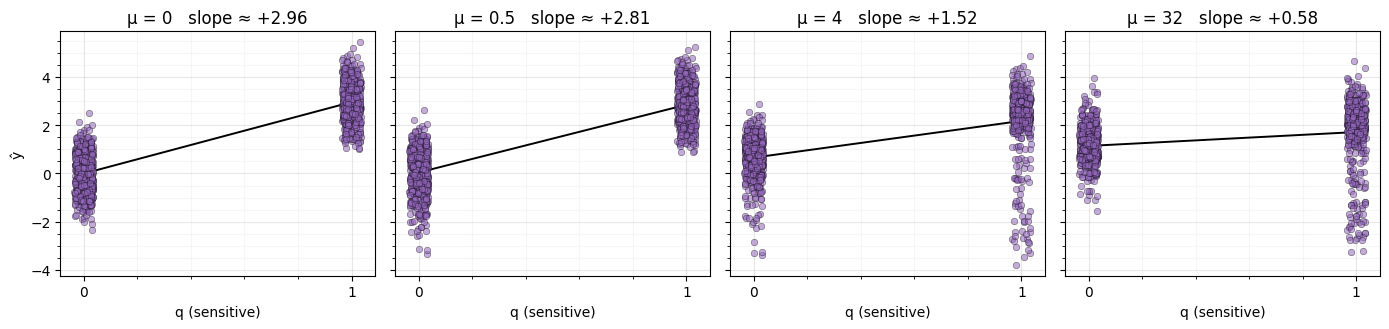

In [8]:
fig, axes = plt.subplots(
    1, len(mus_grid), figsize=(3.5 * len(mus_grid), 3.4), sharey=True
)
for ax, mu in zip(axes, mus_grid, strict=True):
    yh = runs[mu]["yh"]
    jitter = 0.07 * (np.random.RandomState(0).rand(len(q_test)) - 0.5)
    ax.scatter(q_test + jitter, yh, color=G_COLOR, **SCATTER_KW)
    # Trend line
    slope = np.polyfit(q_test, yh, 1)
    qx = np.array([0, 1])
    ax.plot(qx, slope[1] + slope[0] * qx, "k-", lw=1.4)
    ax.set_title(f"μ = {mu:g}   slope ≈ {slope[0]:+.2f}")
    ax.set_xlabel("q (sensitive)")
    ax.set_xticks([0, 1])
    style_ax(ax)
axes[0].set_ylabel("ŷ")
plt.tight_layout()
plt.show()

**What to notice.** At $\mu = 0$ the best-fit slope is essentially
the data-generating $+3$ — the MLP has faithfully recovered the
unfair structure. By $\mu = 32$ the slope has been driven close to
zero: same $q$ value, same distribution of predictions. Between
those endpoints the slope traces a smooth descent, which is exactly
what one wants from a continuous fairness knob. The model still
makes predictions — they are just no longer keyed on $q$.

## 7. The Pareto curve — G-XCOV vs. CKA, three seeds

Loss curves and scatter plots show one configuration. The held-out
Pareto curve shows the *family* of trade-offs you can buy. We
re-run the sweep at six $\mu$ values and three seeds for each of
**G-XCOV** (this work) and **CKA** (the fairkl baseline) — same
wrapper, same MLP, same data, only the fairness loss changes.

In [9]:
def train_eval(fairness_loss, mu: float, seed: int) -> dict:
    keras.utils.set_random_seed(seed)
    mlp = build_mlp(d=X_train.shape[1])
    model = FairModelWrapper(mlp, mu=mu, fairness_loss=fairness_loss)
    model.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse")
    model.fit(
        X_train,
        y_train,
        q=q_train,
        epochs=60,
        batch_size=256,
        verbose=0,
    )
    yh = np.asarray(model.predict(X_test, verbose=0)).ravel()
    return {
        "rmse": float(np.sqrt(np.mean((yh - y_test) ** 2))),
        "abs_corr": pearson_corr(yh, q_test),
        "gap": float(abs(yh[q_test == 1].mean() - yh[q_test == 0].mean())),
        "p_hi_q1": float(yh[q_test == 1].mean()),
        "p_hi_q0": float(yh[q_test == 0].mean()),
    }


mus = [0.0, 0.05, 0.5, 2.0, 8.0, 32.0]
seeds = [0, 1, 2]
cka_loss = CKALoss(sigma_f=1.0, sigma_q=1.0, kernel="rbf", debiased=False)

records = []
for fam_name, loss in [("g_xcov", g_loss), ("cka", cka_loss)]:
    for mu in mus:
        for s in seeds:
            r = train_eval(loss, mu=mu, seed=s)
            r["family"], r["mu"], r["seed"] = fam_name, mu, s
            records.append(r)
print(f"completed {len(records)} runs")

completed 36 runs


In [10]:
def aggregate(fam: str) -> list[dict]:
    out = []
    for mu in mus:
        rows = [r for r in records if r["family"] == fam and r["mu"] == mu]
        out.append(
            {
                "mu": mu,
                "rmse_m": np.mean([r["rmse"] for r in rows]),
                "rmse_s": np.std([r["rmse"] for r in rows]),
                "corr_m": np.mean([r["abs_corr"] for r in rows]),
                "corr_s": np.std([r["abs_corr"] for r in rows]),
                "gap_m": np.mean([r["gap"] for r in rows]),
                "gap_s": np.std([r["gap"] for r in rows]),
                "phi_q1_m": np.mean([r["p_hi_q1"] for r in rows]),
                "phi_q0_m": np.mean([r["p_hi_q0"] for r in rows]),
            }
        )
    return out


agg_g = aggregate("g_xcov")
agg_c = aggregate("cka")

print(f"\n{'family':>7s} {'mu':>6s} {'RMSE':>15s} {'|corr|':>15s} {'gap':>15s}")
for fam, rows in [("g_xcov", agg_g), ("cka", agg_c)]:
    for r in rows:
        print(
            f"{fam:>7s} {r['mu']:>6.2f} "
            f"{r['rmse_m']:7.3f}±{r['rmse_s']:5.3f} "
            f"{r['corr_m']:7.3f}±{r['corr_s']:5.3f} "
            f"{r['gap_m']:7.3f}±{r['gap_s']:5.3f}"
        )


 family     mu            RMSE          |corr|             gap
 g_xcov   0.00   0.108±0.003   0.876±0.001   2.967±0.004
 g_xcov   0.05   0.110±0.002   0.872±0.002   2.954±0.003
 g_xcov   0.50   0.194±0.003   0.842±0.002   2.824±0.017
 g_xcov   2.00   0.507±0.008   0.742±0.008   2.375±0.017
 g_xcov   8.00   1.191±0.030   0.414±0.023   1.112±0.049
 g_xcov  32.00   1.354±0.024   0.223±0.020   0.517±0.042
    cka   0.00   0.108±0.003   0.876±0.001   2.967±0.004
    cka   0.05   0.110±0.002   0.870±0.001   2.952±0.005
    cka   0.50   0.240±0.007   0.813±0.002   2.768±0.003
    cka   2.00   0.610±0.011   0.666±0.004   2.228±0.009
    cka   8.00   1.123±0.042   0.367±0.024   1.059±0.036
    cka  32.00   1.403±0.023   0.106±0.026   0.219±0.055


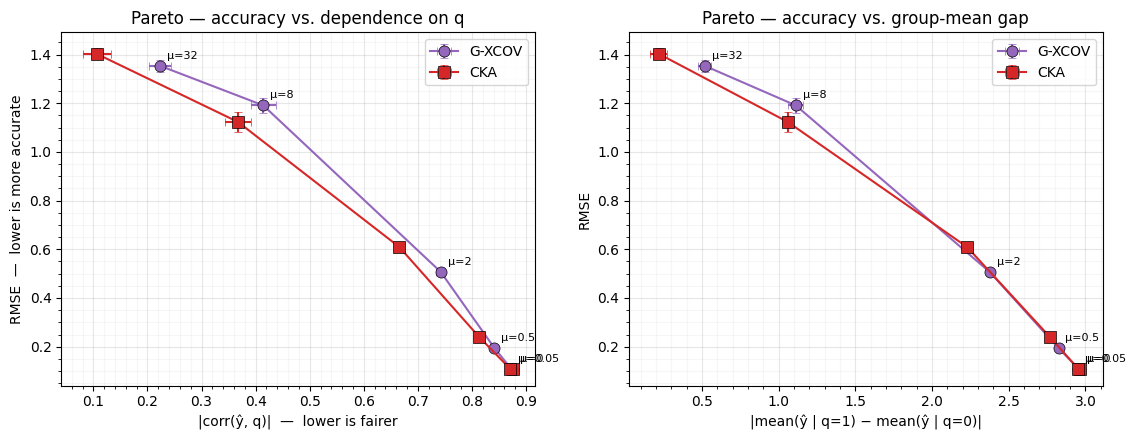

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

for fam, rows, marker, color in [
    ("G-XCOV", agg_g, "o", G_COLOR),
    ("CKA", agg_c, "s", CKA_COLOR),
]:
    rmse_m = np.array([r["rmse_m"] for r in rows])
    rmse_s = np.array([r["rmse_s"] for r in rows])
    corr_m = np.array([r["corr_m"] for r in rows])
    corr_s = np.array([r["corr_s"] for r in rows])
    gap_m = np.array([r["gap_m"] for r in rows])
    gap_s = np.array([r["gap_s"] for r in rows])

    axes[0].errorbar(
        corr_m,
        rmse_m,
        xerr=corr_s,
        yerr=rmse_s,
        marker=marker,
        color=color,
        label=fam,
        capsize=3,
        lw=1.5,
        markersize=8,
        markeredgecolor="k",
        markeredgewidth=0.5,
    )
    axes[1].errorbar(
        gap_m,
        rmse_m,
        xerr=gap_s,
        yerr=rmse_s,
        marker=marker,
        color=color,
        label=fam,
        capsize=3,
        lw=1.5,
        markersize=8,
        markeredgecolor="k",
        markeredgewidth=0.5,
    )
    if fam == "G-XCOV":
        for mu, x, y in zip(mus, corr_m, rmse_m, strict=True):
            axes[0].annotate(
                f"μ={mu:g}",
                (x, y),
                fontsize=8,
                xytext=(5, 5),
                textcoords="offset points",
            )
        for mu, x, y in zip(mus, gap_m, rmse_m, strict=True):
            axes[1].annotate(
                f"μ={mu:g}",
                (x, y),
                fontsize=8,
                xytext=(5, 5),
                textcoords="offset points",
            )

axes[0].set_xlabel("|corr(ŷ, q)|  —  lower is fairer")
axes[0].set_ylabel("RMSE  —  lower is more accurate")
axes[0].set_title("Pareto — accuracy vs. dependence on q")
axes[0].legend(fontsize=10)
style_ax(axes[0])

axes[1].set_xlabel("|mean(ŷ | q=1) − mean(ŷ | q=0)|")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Pareto — accuracy vs. group-mean gap")
axes[1].legend(fontsize=10)
style_ax(axes[1])

plt.tight_layout()
plt.show()

**What to notice.** The cost of fairness is *not linear* for either
loss: the first units come almost free (an elbow near $\mu \approx
0.5$ where dependence drops sharply for a few hundredths of RMSE),
while the last units are expensive (the model must abandon the $3q$
component of the target outright, and no other feature can recover
that information). G-XCOV and CKA trace similar fronts on this
task; the two error bars overlap at most $\mu$ values, with CKA
eking out slightly lower terminal dependence at slightly higher
terminal RMSE. The pragmatic recipe is the same with either loss:
pick the $\mu$ that meets your fairness tolerance, retrain, deploy.

## 8. Group-mean predictions vs. $\mu$ — the parity convergence

One more way to look at the same data: how does the mean predicted
$\hat y$ for each group ($q = 0$ vs $q = 1$) move as $\mu$ grows?
Parity is the point where the two lines meet.

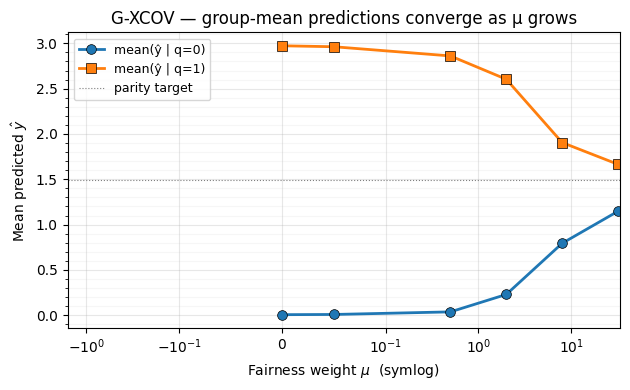

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 4))
mu_arr = np.array(mus)
phi0 = np.array([r["phi_q0_m"] for r in agg_g])
phi1 = np.array([r["phi_q1_m"] for r in agg_g])
ax.plot(
    mu_arr,
    phi0,
    "o-",
    color="tab:blue",
    label="mean(ŷ | q=0)",
    lw=2,
    markersize=7,
    markeredgecolor="k",
    markeredgewidth=0.5,
)
ax.plot(
    mu_arr,
    phi1,
    "s-",
    color="tab:orange",
    label="mean(ŷ | q=1)",
    lw=2,
    markersize=7,
    markeredgecolor="k",
    markeredgewidth=0.5,
)
ax.axhline((phi0[0] + phi1[0]) / 2, color="gray", lw=0.8, ls=":", label="parity target")
ax.set_xscale("symlog", linthresh=0.1)
ax.set_xlabel(r"Fairness weight $\mu$  (symlog)")
ax.set_ylabel(r"Mean predicted $\hat y$")
ax.set_title("G-XCOV — group-mean predictions converge as μ grows")
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** At $\mu = 0$ the two group means are about 3
units apart — the network is reproducing the data-generating
coefficient on $q$. The gap closes monotonically as $\mu$ grows,
and the two lines hit the gray parity target around $\mu \approx
8$. Crucially, *both* lines move — the model brings the $q = 0$
predictions up and the $q = 1$ predictions down, finding a
compromise that keeps overall fit reasonable.

Onward to notebook 07: the same picture on UCI Adult Census, where
the unfairness is real and the sensitive attribute is gender.